In [1]:
import seaborn as sns
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split

In [13]:
# getting the data
data= pd.read_csv("Titanic-Dataset.csv")
data.head()
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
# to fill the null values
from sklearn.impute import SimpleImputer
Imp_median = SimpleImputer(strategy="median")
Imp_Frq = SimpleImputer(strategy="most_frequent")
data["Age"] = Imp_median.fit_transform(data[["Age"]]).ravel()
data["Embarked"] = Imp_Frq.fit_transform(data[["Embarked"]]).ravel()

In [17]:
# encoding of the features
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
data["Embarked"] = le.fit_transform(data["Embarked"])
data["Sex"] = le.fit_transform(data["Sex"])
data["Embarked"] = le.fit_transform(data["Embarked"])

In [20]:
# Test Train Split
x = data[["Pclass", "Sex", "Age", "Fare", "Embarked"]]
y = data["Survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2)


In [26]:
# implement the model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
DT = DecisionTreeClassifier()
DT.fit(x_train, y_train)
y_pred = DT.predict(x_test)
print("accuracy score is ", accuracy_score(y_test, y_pred))


accuracy score is  0.770949720670391


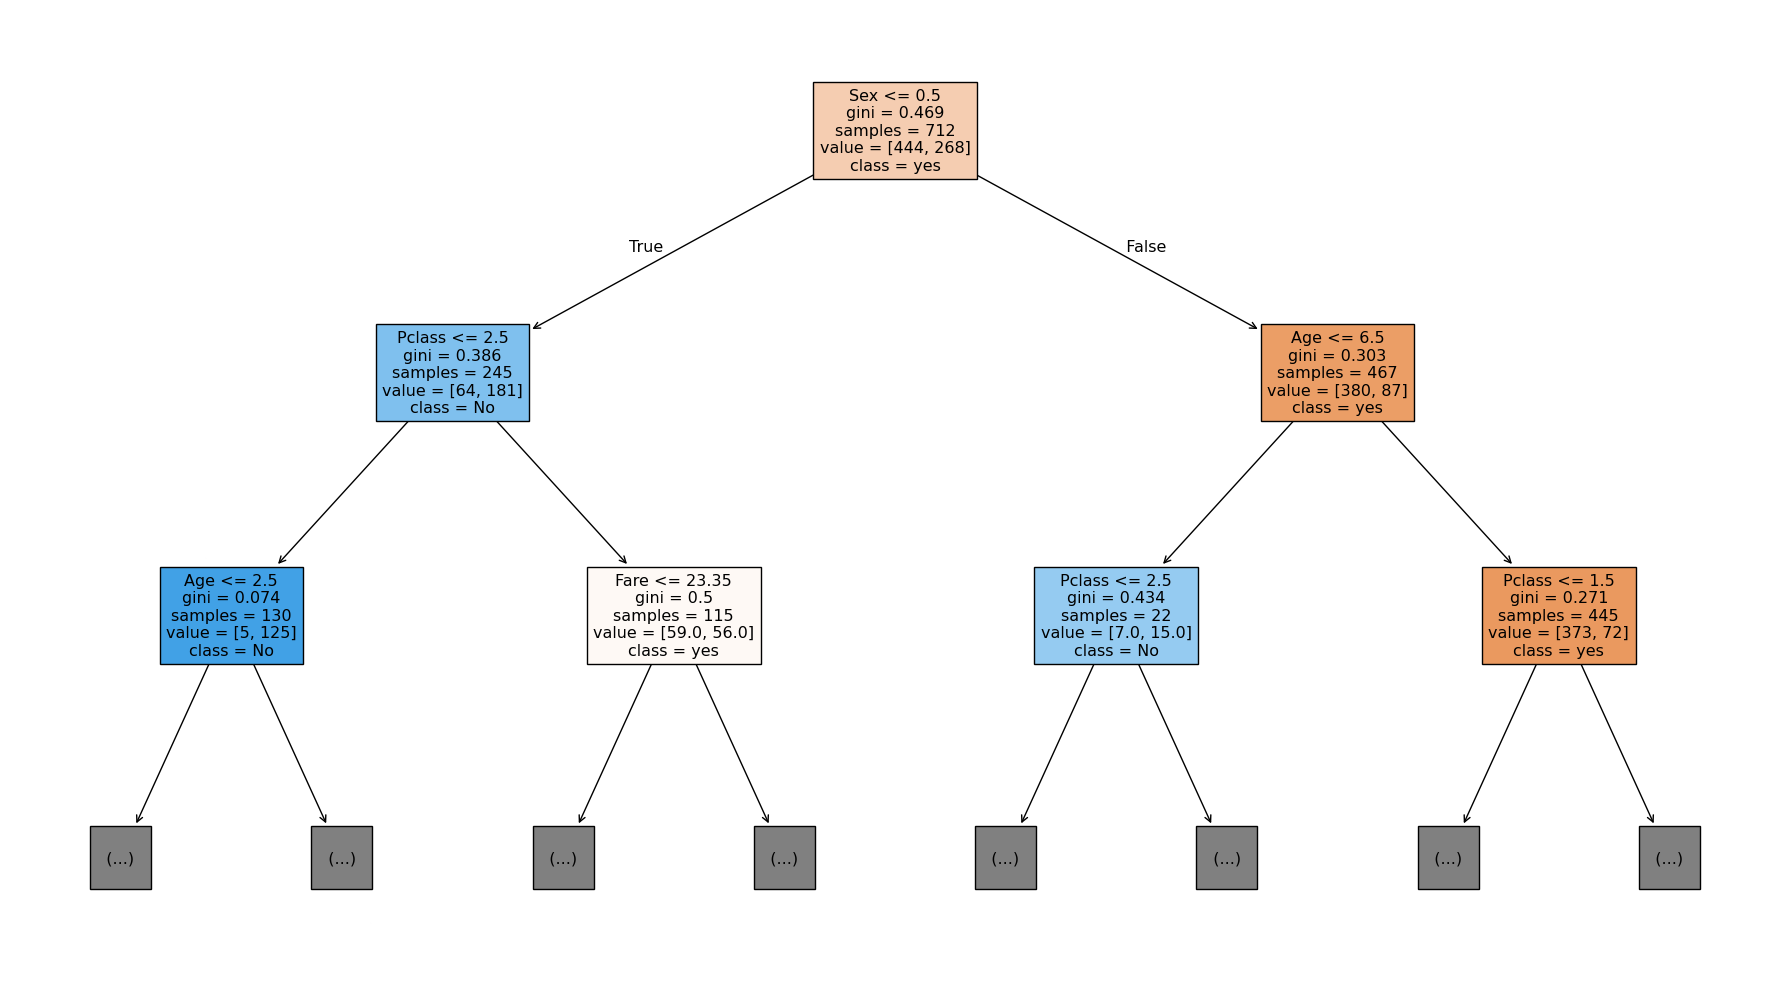

In [36]:
# Ploting a tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18,10))
plot_tree(
    DT,
    feature_names = x.columns,
    class_names = ["yes","No"],
    filled = True,
    max_depth=2)
plt.tight_layout()
plt.show()
    

# Decision Trees with Pre-Prunning


In [43]:
# pre_pruning for the max_depth
Mx_depth = [2,4,5,6,7,8,10,12,14,]
for i in Mx_depth:
    DT = DecisionTreeClassifier(max_depth=i)
    DT.fit(x_train, y_train)
    acc = DT.score(x_test, y_test)
    print(f"The depth value {i} result in the accuracy of {acc}")

# pre_pruning with max_leap_nodes
Mx_LD = [2,4,5,6,7,8,10,12,14,20,30,40]
for i in Mx_LD:
    DT = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=i)
    DT.fit(x_train, y_train)
    acc = DT.score(x_test, y_test)
    print(f"The Max_Leaf_Nodes {i} result in the accuracy of {acc}")

The depth value 2 result in the accuracy of 0.7653631284916201
The depth value 4 result in the accuracy of 0.7988826815642458
The depth value 5 result in the accuracy of 0.7988826815642458
The depth value 6 result in the accuracy of 0.7988826815642458
The depth value 7 result in the accuracy of 0.7988826815642458
The depth value 8 result in the accuracy of 0.7932960893854749
The depth value 10 result in the accuracy of 0.7988826815642458
The depth value 12 result in the accuracy of 0.7877094972067039
The depth value 14 result in the accuracy of 0.770949720670391
The Max_Leaf_Nodes 2 result in the accuracy of 0.7821229050279329
The Max_Leaf_Nodes 4 result in the accuracy of 0.7653631284916201
The Max_Leaf_Nodes 5 result in the accuracy of 0.7932960893854749
The Max_Leaf_Nodes 6 result in the accuracy of 0.7932960893854749
The Max_Leaf_Nodes 7 result in the accuracy of 0.7988826815642458
The Max_Leaf_Nodes 8 result in the accuracy of 0.7988826815642458
The Max_Leaf_Nodes 10 result in the

# Decision Trees with Post-Prunning


In [44]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
path= full_tree.cost_complexity_pruning_path(x_train, y_train)
ccp_val = path.ccp_alphas
ccp_val

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [59]:
# train our model for all the alphas values to get the best result
tree = []
for alpha in ccp_val:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(x_train, y_train)
    tree.append((alpha,model))
    
best_acc = 0
best_alpha = 0
for alpha, model in tree:
    current_acc = model.score(x_test,y_test)
    if current_acc>best_acc:
        best_acc= current_acc
        best_alpha = alpha


In [61]:
best_acc
best_alpha

np.float64(0.0015407231242023183)

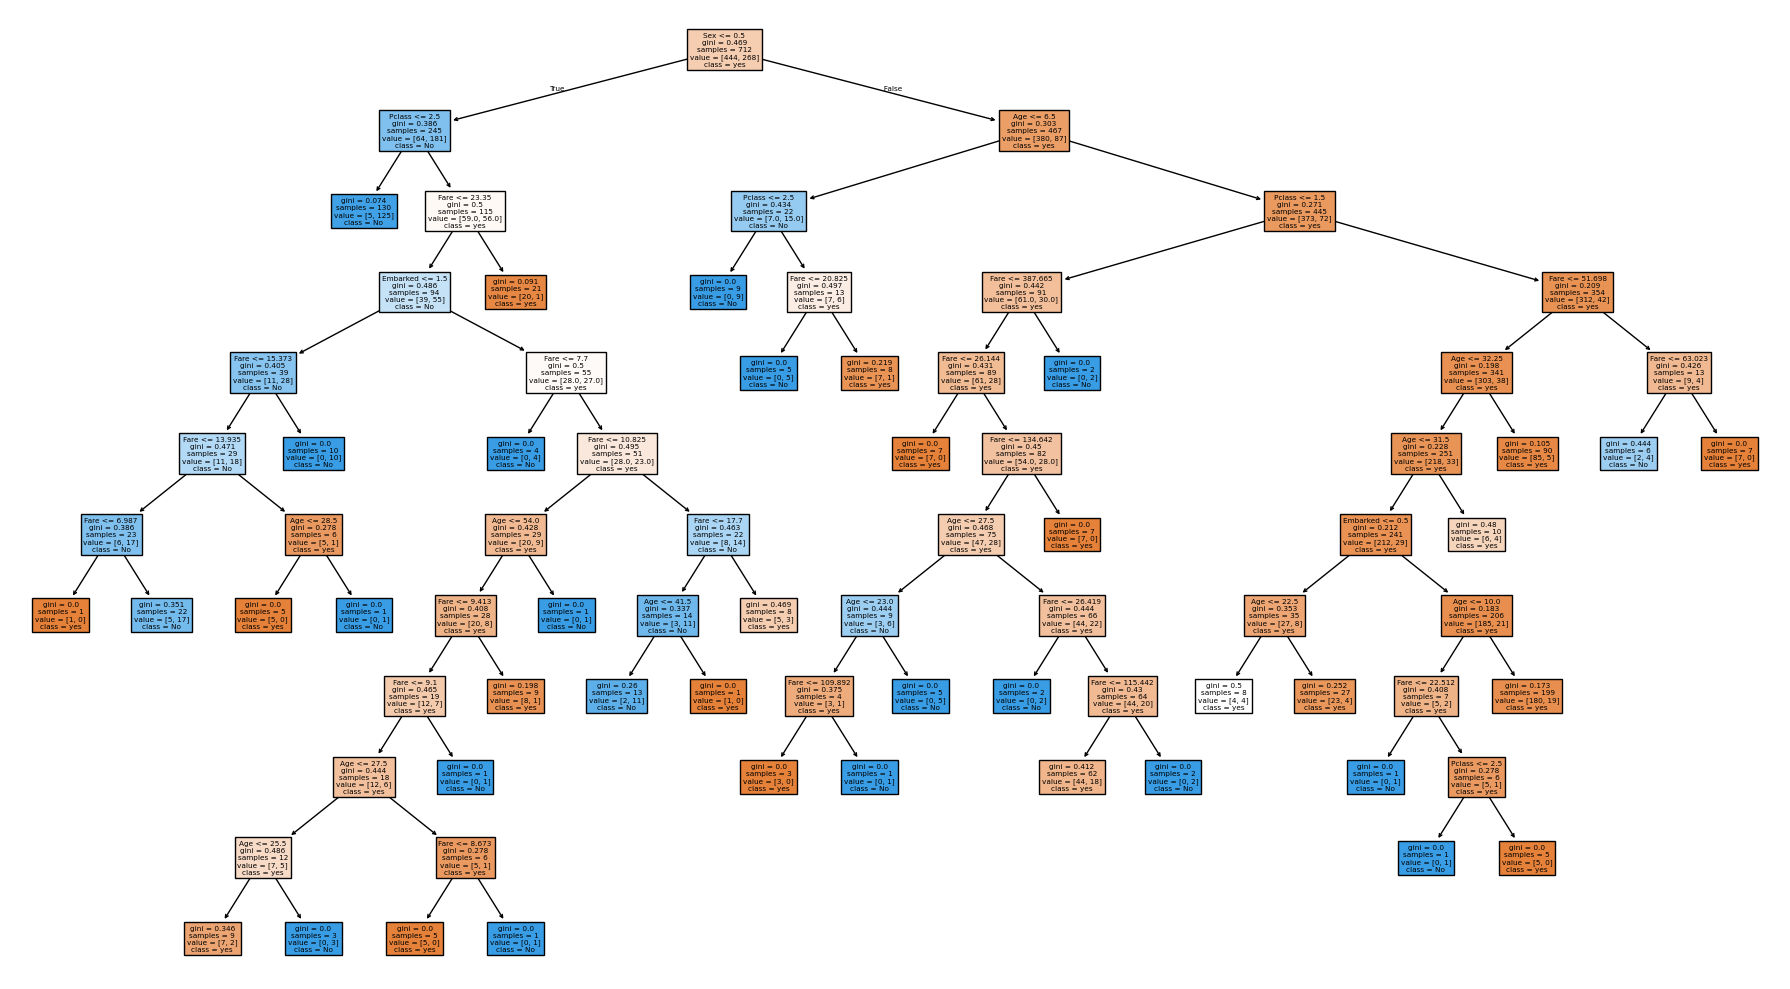

In [63]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit (x_train, y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = x.columns,
    class_names = ["yes","No"],
    filled = True,
    )
plt.tight_layout()
plt.show()
    

In [70]:
# TO build a decisoin Tree Classifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import load_diabetes
df = load_diabetes(as_frame = True).frame
x = df.drop("target", axis = 1)
y = df["target"]
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)
DTR = DecisionTreeClassifier()
DTR.fit(x_train, y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


MSE train : 0.0
MSE test : 5432.6741573033705
R2 train : 1.0
R2 Test : -0.025390440888076293


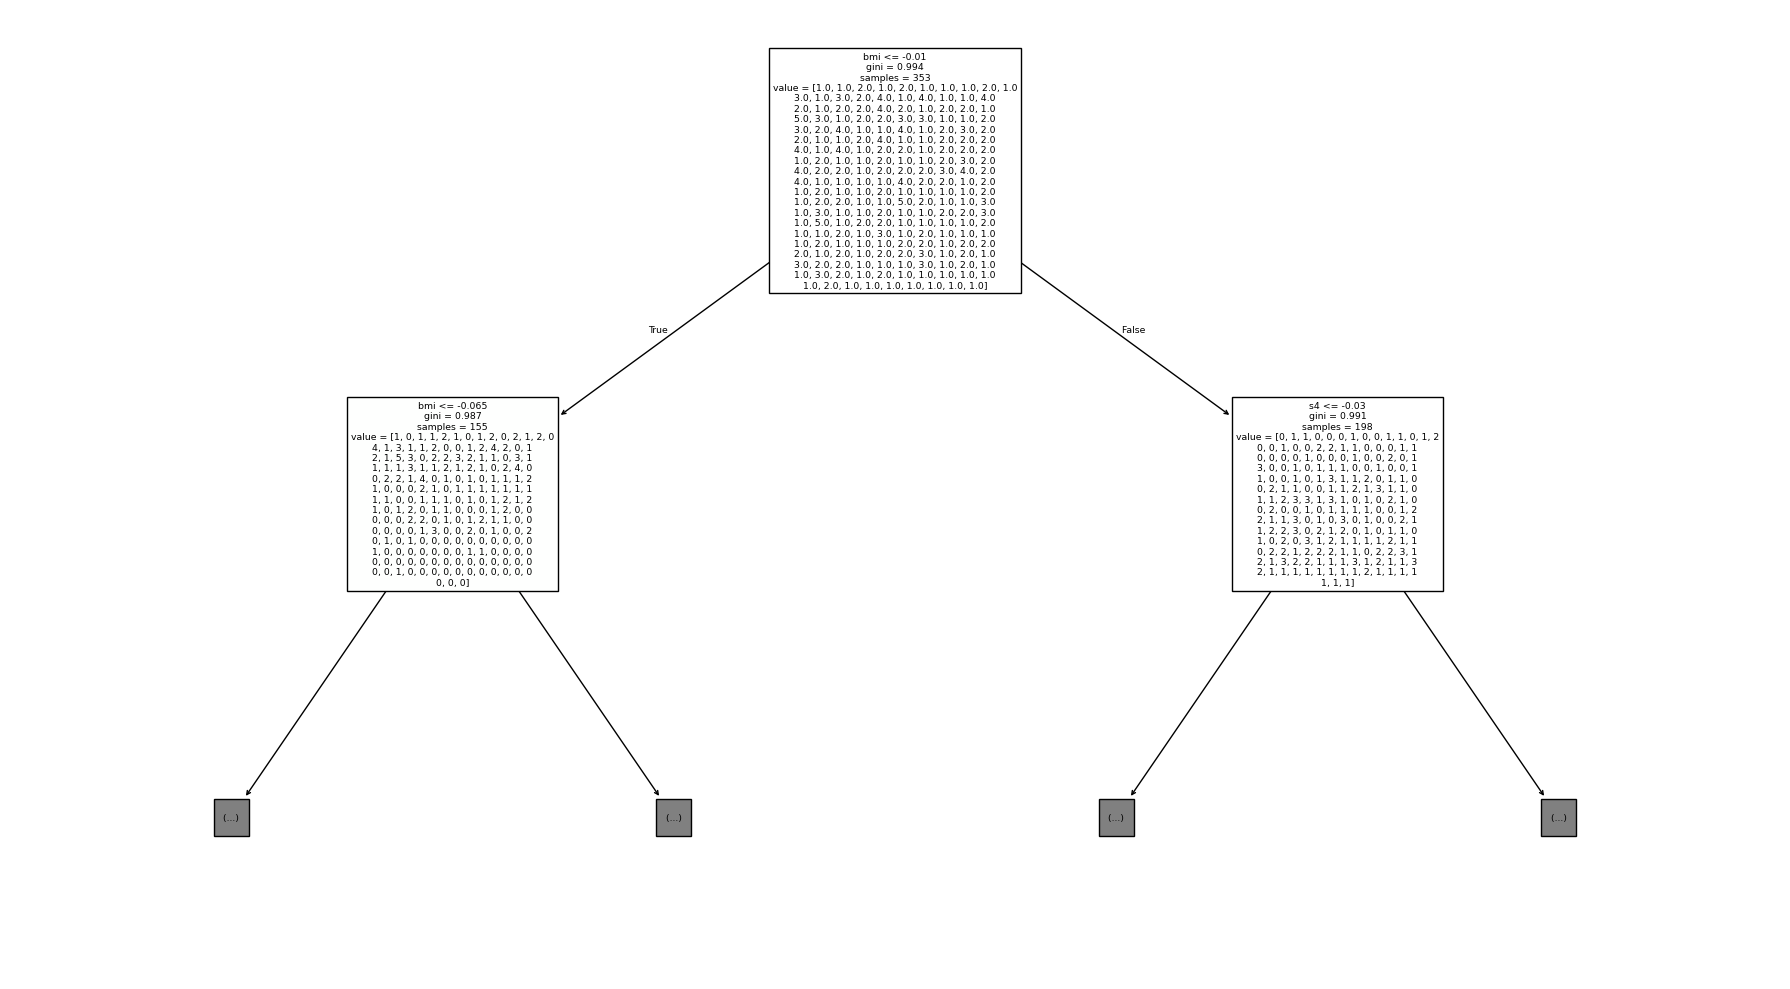

In [79]:
from sklearn.metrics import r2_score, mean_squared_error
y_train_pred = DTR.predict(x_train)
y_test_pred = DTR.predict(x_test)

print("MSE train :", mean_squared_error(y_train, y_train_pred))
print("MSE test :", mean_squared_error(y_test, y_test_pred))
print("R2 train :", r2_score(y_train, y_train_pred))
print("R2 Test :", r2_score(y_test, y_test_pred))

from sklearn.tree import plot_tree
plt.figure(figsize= (18,10))
plot_tree(
    DTR,
    feature_names = x.columns, 
    filled = True,
    max_depth = 1)
plt.tight_layout()

# ASSIGNMENT 04- IMPLEMENT THE DECISION BASED CLASSIFIER

In [137]:
import pandas as pd
import numpy as np 
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [121]:
dataas = pd.read_csv("shop_smart_ecommerce.csv")
dataas.head()
dataas.info()
dataas.isnull().sum()
dataas.columns
dataas["VisitorType"].unique()
dataas["Month"].unique()
dataas["Revenue"].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

array([False,  True])

In [122]:
# Encoding of the data
labE = LabelEncoder()
dataas["Revenue"] = labE.fit_transform(dataas["Revenue"])
dataas["Weekend"] = labE.fit_transform(dataas["Weekend"])

oneE = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
cols = ["Month", "VisitorType"]
encoded = oneE.fit_transform(dataas[cols])
# for one hot encoder we need to transform it into dataframe again

encoded_df = pd.DataFrame(encoded,columns= oneE.get_feature_names_out(cols), index=dataas.index)

dataas = pd.concat([dataas.drop(columns=cols), encoded_df], axis = 1)


In [128]:
# spliting the data
x = dataas.drop("Revenue", axis =1)
y = dataas["Revenue"]
xa_train, xa_test, ya_train, ya_test = train_test_split(x,y, random_state=42, test_size=0.2)

tree = DecisionTreeClassifier(max_depth=6,              # prevents deep overfitting
min_samples_leaf=30,      # smooths decision boundaries
class_weight="balanced",  # handles imbalance
random_state=42)
tree.fit(xa_train, ya_train)
pred = tree.predict(xa_test)
print(f"The value of the max Depth {i} result in these results")
#print("The Precision value is :", precision_score(ya_test,pred))
#print("The Accuracy value is :", accuracy_score(ya_test, pred))
print("The  F1_score value is :", f1_score(ya_test, pred))
#print("The Recall_score value is :", recall_score(ya_test, pred))

The value of the max Depth 10 result in these results
The  F1_score value is : 0.6356011183597391


In [140]:
# second approach
num_col = x.select_dtypes(include=["int64", "float64"]).columns
cat_col = x.select_dtypes(include=["object", "category"]).columns

pre_processor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col)])

pipe = Pipeline(
    steps=[
        ("preprocess", pre_processor),
        ("model", tree)
    ]
)
pipe.fit(xa_train, ya_train)
y_pred = pipe.predict(xa_test)
print("The  F1_score value is :", f1_score(ya_test, y_pred))


The  F1_score value is : 0.6356011183597391


8916     0
772      1
12250    0
7793     0
6601     0
        ..
295      1
3694     0
4974     0
10383    1
2611     0
Name: Revenue, Length: 2466, dtype: int64

In [141]:
xa_test

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
8916,3,142.500000,0,0.00,48,1052.255952,0.004348,0.013043,0.000000,0.0,1,8,6,11,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
772,6,437.391304,2,235.55,83,2503.881781,0.002198,0.004916,2.086218,0.0,2,2,3,2,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
12250,1,41.125000,0,0.00,126,4310.004668,0.000688,0.012823,3.451072,0.0,2,2,2,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7793,2,141.000000,0,0.00,10,606.666667,0.008333,0.026389,36.672294,0.0,2,5,7,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6601,18,608.140000,6,733.80,168,4948.398759,0.006632,0.013528,10.150644,0.0,2,2,3,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0,0.000000,0,0.00,13,328.916667,0.000000,0.014286,59.790143,0.0,3,2,1,3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3694,0,0.000000,0,0.00,8,211.333333,0.000000,0.075000,0.000000,0.0,2,5,3,2,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4974,0,0.000000,2,23.00,52,4167.488095,0.009615,0.024840,0.000000,0.0,2,2,3,1,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10383,3,53.000000,5,9.50,218,8205.687940,0.023570,0.039664,1.180737,0.0,1,1,3,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [142]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(xa_train)
x_test_scaled = sc.transform(xa_test)
tree = DecisionTreeClassifier(max_depth=6,              # prevents deep overfitting
min_samples_leaf=30,      # smooths decision boundaries
class_weight="balanced",  # handles imbalance
random_state=42)
tree.fit(x_train_scaled, ya_train)
pred = tree.predict(x_test_scaled)
print("The  F1_score value is :", f1_score(ya_test, pred))


The  F1_score value is : 0.6356011183597391
